In [ ]:
# ✅ Step 1: Upload CSV file to Colab
from google.colab import files
uploaded = files.upload()  # Upload 'Mall_Customers.csv'

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
# ✅ Step 2: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# ✅ Step 3: Load the dataset
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# ✅ Step 4: Basic EDA
print(df.info())
print(df.describe())

# Optional: Rename columns if needed
df.rename(columns={'Genre': 'Gender'}, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000    

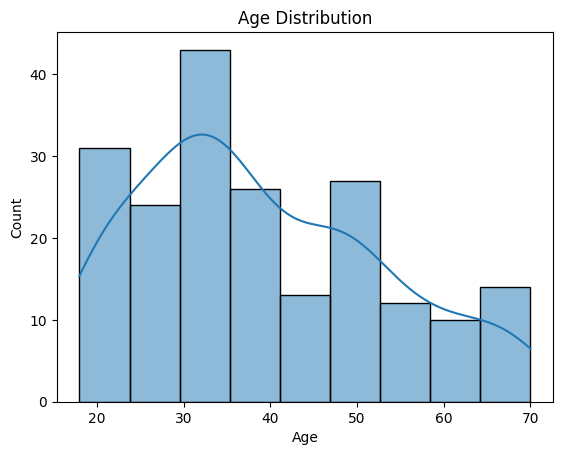

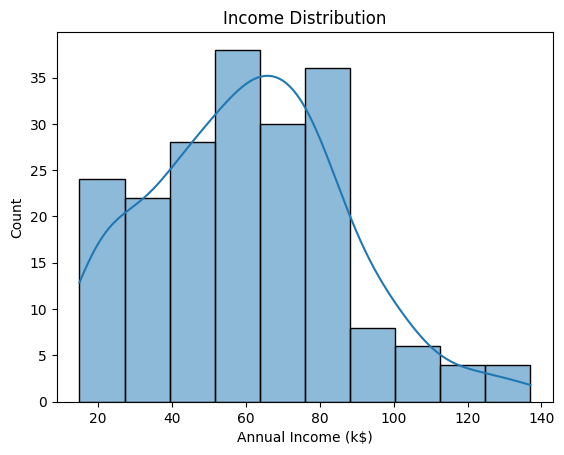

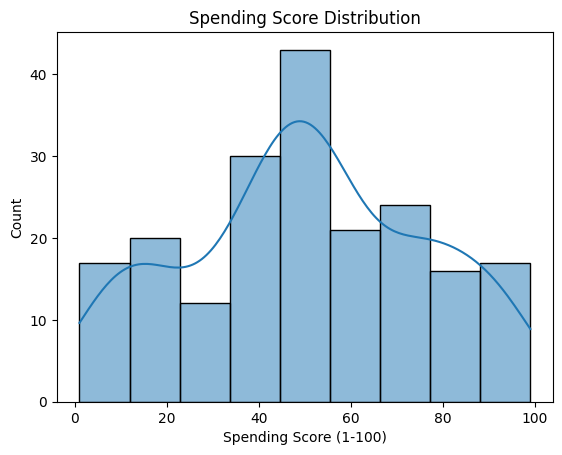

In [ ]:
# ✅ Step 5: Visualize distributions
sns.histplot(data=df, x='Age', kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(data=df, x='Annual Income (k$)', kde=True)
plt.title("Income Distribution")
plt.show()

sns.histplot(data=df, x='Spending Score (1-100)', kde=True)
plt.title("Spending Score Distribution")
plt.show()


In [ ]:
# ✅ Step 6: Encode categorical column (Gender)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [ ]:
# ✅ Step 7: Select features for clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

In [ ]:
# ✅ Step 8: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

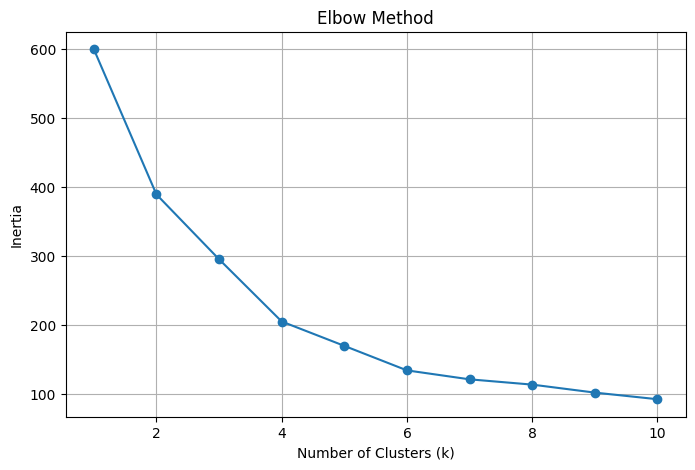

In [ ]:
# ✅ Step 9: Elbow Method to find optimal k
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [ ]:
# ✅ Step 10: Apply KMeans clustering (choose k=5 from elbow method)
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

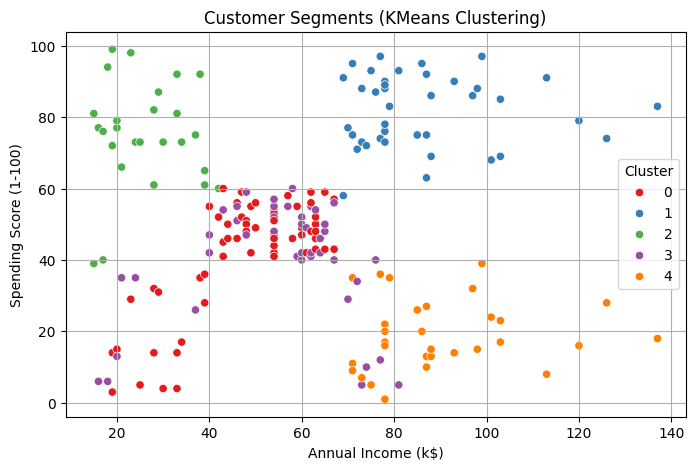

In [ ]:
# ✅ Step 11: Visualize Clusters
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1')
plt.title("Customer Segments (KMeans Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(True)
plt.show()

In [ ]:
# ✅ Step 12: Optional - Cluster Profiling
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print(cluster_summary)

           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        55.28               47.62                   41.71
1        32.88               86.10                   81.53
2        25.77               26.12                   74.85
3        26.73               54.31                   40.91
4        44.39               89.77                   18.48


In [ ]:
# ✅ Step 13: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
# ✅ Step 14: Load data
df = pd.read_csv('Mall_Customers.csv')
df.rename(columns={'Genre': 'Gender'}, inplace=True)
print("📌 Dataset Shape:", df.shape)
display(df.head())

📌 Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



✅ Data Types and Null Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

📈 Summary Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


/tmp/ipython-input-3895170410.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='Set2')


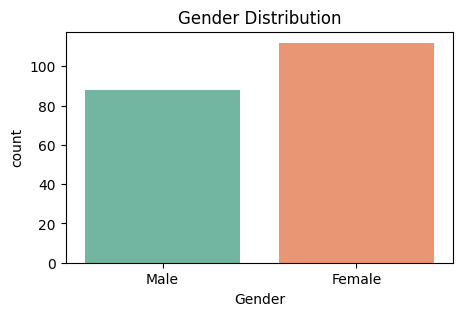

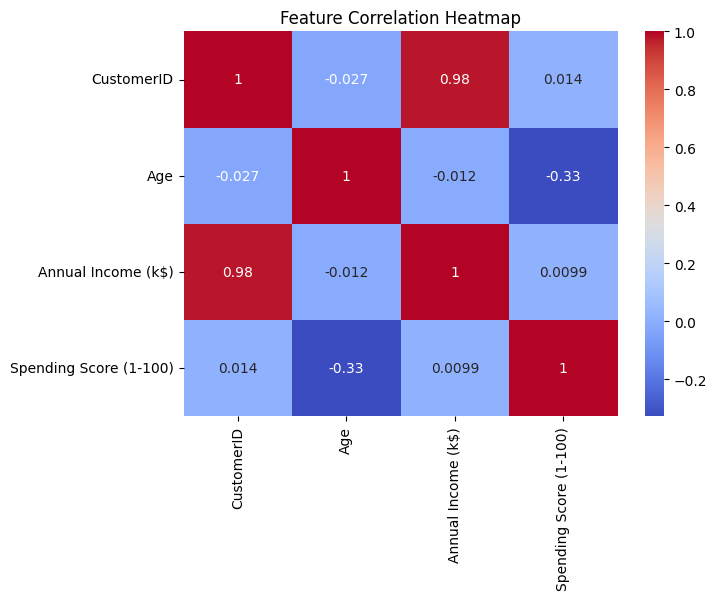

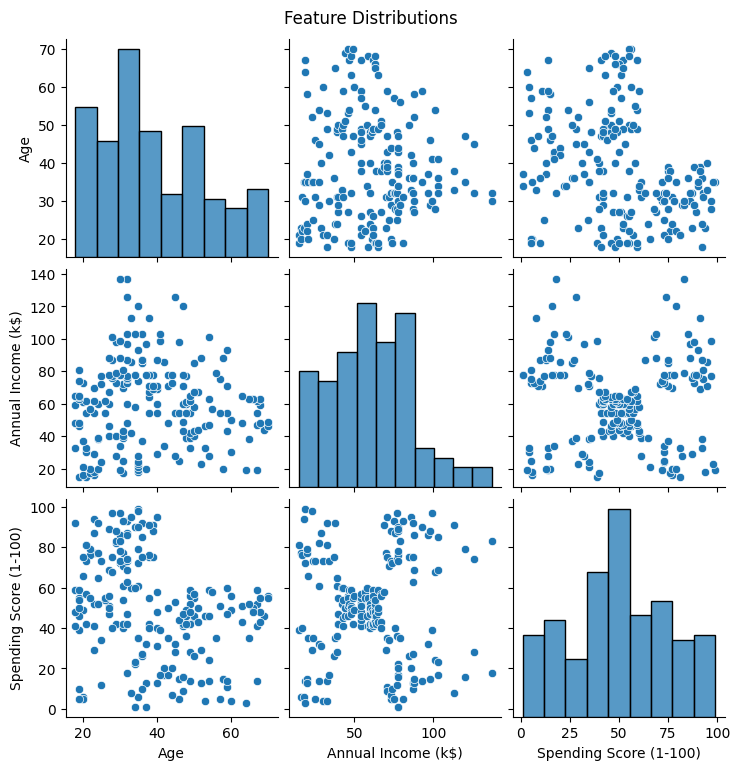

In [ ]:
# ✅ Step 15: Exploratory Data Analysis
print("\n✅ Data Types and Null Values:")
print(df.info())

print("\n📈 Summary Statistics:")
display(df.describe())

# Gender distribution
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='Gender', palette='Set2')
plt.title("Gender Distribution")
plt.show()

# Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# PairPlot
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

In [ ]:
# ✅ Step 16: Data Preprocessing
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

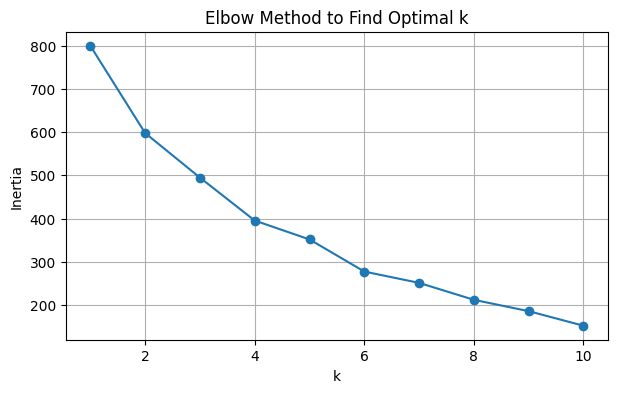

In [ ]:
# ✅ Step 17: Elbow Method
inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method to Find Optimal k")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [ ]:
# ✅ Step 18: Apply KMeans (k=5)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# ✅ Step 19: Evaluate Clustering
score = silhouette_score(X_scaled, df['Cluster'])
print(f"✅ Silhouette Score for k={k}: {score:.3f}")

✅ Silhouette Score for k=5: 0.272


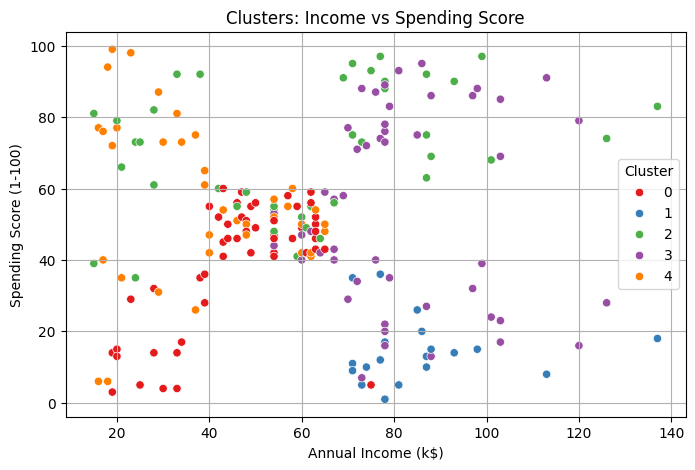

/tmp/ipython-input-1486594039.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set3')


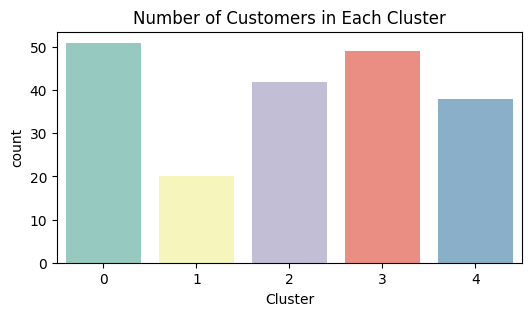

In [ ]:
# ✅ Step 20: Cluster Visualizations
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1')
plt.title("Clusters: Income vs Spending Score")
plt.grid(True)
plt.show()

# Cluster size
plt.figure(figsize=(6,3))
sns.countplot(x='Cluster', data=df, palette='Set3')
plt.title("Number of Customers in Each Cluster")
plt.show()

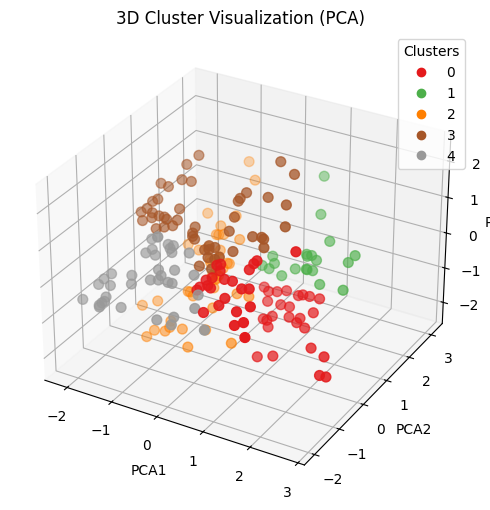

In [ ]:
# ✅ Step 21: PCA for 3D Visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'], df['PCA3'] = X_pca[:,0], X_pca[:,1], X_pca[:,2]

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['PCA1'], df['PCA2'], df['PCA3'], c=df['Cluster'], cmap='Set1', s=50)
ax.set_title("3D Cluster Visualization (PCA)")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [ ]:
# ✅ Step 22: Cluster Profiling Table
cluster_profile = df.groupby('Cluster')[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
cluster_profile['Customers'] = df['Cluster'].value_counts().sort_index()
print("\n📊 Cluster Profiling Summary:")
display(cluster_profile)


📊 Cluster Profiling Summary:


,Gender,Age,Annual Income (k$),Spending Score (1-100),Customers
Cluster,,,,,
0,0.49,56.47,46.10,39.31,51
1,0.00,39.50,85.15,14.05,20
2,0.00,28.69,60.90,70.24,42
3,1.00,37.90,82.12,54.45,49
4,1.00,27.32,38.84,56.21,38
